## Bayesian Optimisation Over Molecules ##

An example notebook for Bayesian optimisation on a molecular dataset using a Tanimoto fingerprint kernel and the photoswitch dataset

Paper: https://pubs.rsc.org/en/content/articlelanding/2022/sc/d2sc04306h

Code: https://github.com/Ryan-Rhys/The-Photoswitch-Dataset

A key aspect of this Bayesian optimisation loop is that the queried molecules, $\mathbf{x^*}$. are drawn from a discrete set of heldout molecules, $\mathcal{D}_{\text{heldout}}$. Such situations may arise in virtual screening campaigns where one wishes to select a molecule for synthesis from a virtual library. In this case the acquisition function is evaluated on a discrete set and the maximum of the set is taken as the proposed candidate at each iteration of Bayesian optimisation.

In [17]:
"""Imports."""

import time
import warnings
warnings.filterwarnings("ignore") # Turn off Graphein warnings

from matplotlib import pyplot as plt
%matplotlib inline

import numpy as np
import torch
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.exceptions import BadInitialCandidatesWarning
from botorch.models.gp_regression import SingleTaskGP
from gpytorch.distributions import MultivariateNormal
from gpytorch.kernels import ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ConstantMean
from gpytorch.mlls import ExactMarginalLogLikelihood
from sklearn.model_selection import train_test_split

from gauche.dataloader import MolPropLoader

We define our model. See

https://docs.gpytorch.ai/en/latest/examples/01_Exact_GPs/Simple_GP_Regression.html

for further examples!

In [18]:
from gpytorch.kernels import RBFKernel, ScaleKernel, ProductKernel
from gpytorch.means import ConstantMean
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.distributions import MultivariateNormal
from botorch.models.gp_regression import SingleTaskGP
from gauche.kernels.fingerprint_kernels.tanimoto_kernel import TanimotoKernel

class TanimotoGP(SingleTaskGP):
    def __init__(self, train_X, train_Y, d_fingerprint=2048):
        super().__init__(train_X, train_Y, likelihood=GaussianLikelihood())

        self.mean_module = ConstantMean()

        # Define individual kernels with active dimensions
        tanimoto_kernel = TanimotoKernel(active_dims=list(range(d_fingerprint)))
        rbf_kernel = RBFKernel(active_dims=[d_fingerprint])  # Assumes 1D temperature

        # Combine using product kernel
        product_kernel = ProductKernel(tanimoto_kernel, rbf_kernel)

        # Wrap in a scale kernel
        self.covar_module = ScaleKernel(base_kernel=product_kernel)

        # Send model to correct device and dtype
        self.to(train_X)

    def transform_inputs(self, X, input_transform=None):
        return X  # Passthrough

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)


We define helper functions for the Bayesian optimisation loop. In particular the acquisition function optimisation procedure is framed so as to take the maximum over a discrete set of heldout molecules.

In [19]:
def initialize_model(train_x, train_obj, state_dict=None):
    """
    Initialise model and loss function.

    Args:
        train_x: tensor of inputs
        train_obj: tensor of outputs
        state_dict: current state dict used to speed up fitting

    Returns: mll object, model object
    """

    # define model for objective
    model = TanimotoGP(train_x, train_obj).to(train_x)
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    # load state dict if it is passed
    if state_dict is not None:
        model.load_state_dict(state_dict)

    return mll, model


def optimize_acqf_and_get_observation(acq_func, heldout_inputs, heldout_outputs):
    """
    Optimizes the acquisition function, and returns a new candidate and an observation.

    Args:
        acq_func: Object representing the acquisition function
        heldout_points: Tensor of heldout points

    Returns: new_x, new_obj
    """

    # Loop over the discrete set of points to evaluate the acquisition function at.
    acq_vals = []
    for i in range(len(heldout_outputs)):
        acq_vals.append(acq_func(heldout_inputs[i].unsqueeze(-2)))  # use unsqueeze to append batch dimension

    # observe new values
    acq_vals = torch.tensor(acq_vals)
    best_idx = torch.argmax(acq_vals)
    new_x = heldout_inputs[best_idx].unsqueeze(-2)  # add batch dimension
    new_obj = heldout_outputs[best_idx].unsqueeze(-1)  # add output dimension

    # Delete the selected input and value from the heldout set.
    heldout_inputs = torch.cat((heldout_inputs[:best_idx], heldout_inputs[best_idx+1:]), axis=0)
    heldout_outputs = torch.cat((heldout_outputs[:best_idx], heldout_outputs[best_idx+1:]), axis=0)

    return new_x, new_obj, heldout_inputs, heldout_outputs


def update_random_observations(best_random, heldout_inputs, heldout_outputs):
    """
    Simulates a random policy by taking a the current list of best values observed randomly,
    drawing a new random point from the heldout set, observing its value, and updating the list.

    Args:
        best_random: List of best random values observed so far
        heldout_inputs: Tensor of inputs
        heldout_outputs: Tensor of output values

    Returns: best_random, float specifying the objective function value.
    """

    # Take a random sample by permuting the indices and selecting the first element.
    index = torch.randperm(len(heldout_outputs))[0]
    next_random_best = heldout_outputs[index]
    best_random.append(max(best_random[-1], next_random_best))

    # Delete the selected input and value from the heldout set.
    heldout_inputs = torch.cat((heldout_inputs[:index], heldout_inputs[index+1:]), axis=0)
    heldout_outputs = torch.cat((heldout_outputs[:index], heldout_outputs[index+1:]), axis=0)

    return best_random, heldout_inputs, heldout_outputs

Run the Bayesian optimisation loop, comparing the analytic (sequential) expected improvement acquisition funciton with a random policy.

In [20]:
import pandas as pd


Trial  1 of 3 
Batch  1: best_value (random, qEI) = (1.92, 1.92), time = 6.10.
Batch  2: best_value (random, qEI) = (1.92, 1.92), time = 10.75.
Batch  3: best_value (random, qEI) = (1.92, 1.92), time = 12.30.
Batch  4: best_value (random, qEI) = (1.92, 1.92), time = 9.60.
Batch  5: best_value (random, qEI) = (1.92, 1.92), time = 7.21.
Batch  6: best_value (random, qEI) = (1.92, 1.92), time = 10.96.
Batch  7: best_value (random, qEI) = (1.92, 1.92), time = 10.04.
Batch  8: best_value (random, qEI) = (1.92, 1.92), time = 10.27.
Batch  9: best_value (random, qEI) = (1.92, 1.98), time = 10.85.
Batch 10: best_value (random, qEI) = (1.92, 1.98), time = 10.83.
Batch 11: best_value (random, qEI) = (1.92, 1.98), time = 10.61.
Batch 12: best_value (random, qEI) = (1.92, 2.09), time = 10.35.
Batch 13: best_value (random, qEI) = (1.92, 2.09), time = 6.01.
Batch 14: best_value (random, qEI) = (1.92, 2.09), time = 6.15.
Batch 15: best_value (random, qEI) = (1.92, 2.09), time = 6.22.
Batch 16: best_

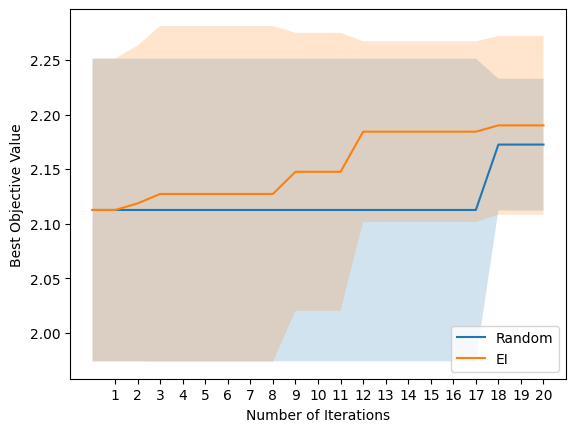

In [23]:
# Bayesian optimisation experiment parameters, number of random trials, split size, batch size
# and number of iterations of Bayesian optimisation.
from concurrent.futures import ProcessPoolExecutor


N_TRIALS = 3
holdout_set_size = 0.95
N_ITERS = 20
verbose = True

# Load the Photoswitch dataset
loader = MolPropLoader()
loader.read_csv(path="./output_data_full.csv", smiles_column="SMILES", label_column="KV")
df = pd.read_csv("./output_data_full.csv")

# We use the fragprints representations (a concatenation of Morgan fingerprints and RDKit fragment features)
loader.featurize('ecfp_fragprints')
X = loader.features
X_temp = df["Temperature (°C)"]
X = np.concatenate((X, X_temp.values.reshape(-1, 1)), axis=1)  # Add temperature as a feature
y = loader.labels

warnings.filterwarnings('ignore', category=BadInitialCandidatesWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

best_observed_all_ei, best_random_all = [], []

# average over multiple random trials (each trial splits the initial training set for the GP in a random manner)
for trial in range(1, N_TRIALS + 1):

    print(f"\nTrial {trial:>2} of {N_TRIALS} ", end="")
    best_observed_ei, best_random = [], []

    # Generate initial training data and initialize model
    train_x_ei, heldout_x_ei, train_y_ei, heldout_y_ei = train_test_split(X, y, test_size=holdout_set_size, random_state=trial)
    best_observed_value_ei = torch.tensor(np.max(train_y_ei))

    # Convert numpy arrays to PyTorch tensors and flatten the label vectors
    train_x_ei = torch.tensor(train_x_ei.astype(np.float64))
    heldout_x_ei = torch.tensor(heldout_x_ei.astype(np.float64))
    train_y_ei = torch.tensor(train_y_ei)
    heldout_y_ei = torch.tensor(heldout_y_ei)

    # The initial heldout set is the same for random search
    heldout_x_random = heldout_x_ei
    heldout_y_random = heldout_y_ei

    mll_ei, model_ei = initialize_model(train_x_ei, train_y_ei)

    best_observed_ei.append(best_observed_value_ei)
    best_random.append(best_observed_value_ei)

    # run N_ITERS rounds of BayesOpt after the initial random batch
    for iteration in range(1, N_ITERS + 1):

        t0 = time.time()

        # fit the model
        fit_gpytorch_mll(mll_ei)

        # Use analytic acquisition function for batch size of 1.
        EI = ExpectedImprovement(model=model_ei, best_f=(train_y_ei.to(train_y_ei)).max())

        new_x_ei, new_obj_ei, heldout_x_ei, heldout_y_ei = optimize_acqf_and_get_observation(EI,
                                                                                             heldout_x_ei,
                                                                                             heldout_y_ei)

        # update training points
        train_x_ei = torch.cat([train_x_ei, new_x_ei])
        train_y_ei = torch.cat([train_y_ei, new_obj_ei])

        # update random search progress
        best_random, heldout_x_random, heldout_y_random = update_random_observations(best_random,
                                                                                     heldout_inputs=heldout_x_random,
                                                                                     heldout_outputs=heldout_y_random)
        best_value_ei = torch.max(new_obj_ei, best_observed_ei[-1])
        best_observed_ei.append(best_value_ei.squeeze())

        # reinitialise the model so it is ready for fitting on the next iteration
        # use the current state dict to speed up fitting
        mll_ei, model_ei = initialize_model(
            train_x_ei,
            train_y_ei,
            model_ei.state_dict(),
        )

        t1 = time.time()

        if verbose:
            print(
                f"\nBatch {iteration:>2}: best_value (random, qEI) = "
                f"({max(best_random).item():>4.2f}, {best_value_ei.item():>4.2f}), "
                f"time = {t1 - t0:>4.2f}.", end=""
            )
        else:
            print(".", end="")

    best_observed_all_ei.append(torch.hstack(best_observed_ei))
    best_random_all.append(torch.hstack(best_random))

# Define a confience interval function for plotting.
def ci(y):
    return 1.96 * y.std(axis=0) / np.sqrt(N_TRIALS)

iters = np.arange(N_ITERS + 1)
y_ei = np.asarray(torch.stack(best_observed_all_ei))
y_rnd = np.asarray(torch.stack(best_random_all))

y_rnd_mean = y_rnd.mean(axis=0)
y_ei_mean = y_ei.mean(axis=0)
y_rnd_std = y_rnd.std(axis=0)
y_ei_std = y_ei.std(axis=0)

lower_rnd = y_rnd_mean - y_rnd_std
upper_rnd = y_rnd_mean + y_rnd_std
lower_ei = y_ei_mean - y_ei_std
upper_ei = y_ei_mean + y_ei_std

plt.plot(iters, y_rnd_mean, label='Random')
plt.fill_between(iters, lower_rnd, upper_rnd, alpha=0.2)
plt.plot(iters, y_ei_mean, label='EI')
plt.fill_between(iters, lower_ei, upper_ei, alpha=0.2)
plt.xlabel('Number of Iterations')
plt.ylabel('Best Objective Value')
plt.legend(loc="lower right")
plt.xticks(list(np.arange(1, 21)))
plt.show()

EI outperforms random search in terms of selecting molecules with high E isomer pi-pi* transition wavelength! It should be noted that the true objective for photoswitch optimisation would consider all transition wavelengths as well as the thermal half-life and this will hopefully be included in a future notebook!

In [25]:
import time
from concurrent.futures import ProcessPoolExecutor

# Experiment parameters
N_TRIALS = 3
holdout_set_size = 0.95
N_ITERS = 20
verbose = True

# Load and featurize data once globally
loader = MolPropLoader()
loader.read_csv(path="./output_data_full.csv", smiles_column="SMILES", label_column="KV")
df = pd.read_csv("./output_data_full.csv")
loader.featurize('ecfp_fragprints')

X = loader.features
X_temp = df["Temperature (°C)"]
X = np.concatenate((X, X_temp.values.reshape(-1, 1)), axis=1)
y = loader.labels

# Suppress warnings
warnings.filterwarnings('ignore', category=BadInitialCandidatesWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Function to run a single trial
def run_trial(trial):
    torch.manual_seed(trial)
    np.random.seed(trial)

    best_observed_ei, best_random = [], []

    train_x, heldout_x, train_y, heldout_y = train_test_split(X, y, test_size=holdout_set_size, random_state=trial)
    best_observed_value = torch.tensor(np.max(train_y))

    train_x = torch.tensor(train_x.astype(np.float64))
    heldout_x = torch.tensor(heldout_x.astype(np.float64))
    train_y = torch.tensor(train_y)
    heldout_y = torch.tensor(heldout_y)

    heldout_x_random = heldout_x.clone()
    heldout_y_random = heldout_y.clone()

    mll, model = initialize_model(train_x, train_y)
    best_observed_ei.append(best_observed_value)
    best_random.append(best_observed_value)

    for iteration in range(1, N_ITERS + 1):
        t0 = time.time()

        fit_gpytorch_mll(mll)
        EI = ExpectedImprovement(model=model, best_f=train_y.max())
        new_x, new_y, heldout_x, heldout_y = optimize_acqf_and_get_observation(EI, heldout_x, heldout_y)

        train_x = torch.cat([train_x, new_x])
        train_y = torch.cat([train_y, new_y])

        best_random, heldout_x_random, heldout_y_random = update_random_observations(
            best_random, heldout_inputs=heldout_x_random, heldout_outputs=heldout_y_random
        )

        best_value = torch.max(new_y, best_observed_ei[-1])
        best_observed_ei.append(best_value.squeeze())

        mll, model = initialize_model(train_x, train_y, model.state_dict())

        t1 = time.time()
        if verbose:
            print(
                f"\nTrial {trial:>2}, Batch {iteration:>2}: best_value (random, qEI) = "
                f"({max(best_random).item():>4.2f}, {best_value.item():>4.2f}), "
                f"time = {t1 - t0:>4.2f}", end=""
            )

    return torch.hstack(best_observed_ei), torch.hstack(best_random)

# Run all trials in parallel
with ProcessPoolExecutor() as executor:
    results = list(executor.map(run_trial, range(1, N_TRIALS + 1)))

best_observed_all_ei, best_random_all = zip(*results)

# Confidence intervals for plotting
def ci(y):
    return 1.96 * y.std(axis=0) / np.sqrt(N_TRIALS)

iters = np.arange(N_ITERS + 1)
y_ei = np.asarray(torch.stack(best_observed_all_ei))
y_rnd = np.asarray(torch.stack(best_random_all))

y_rnd_mean = y_rnd.mean(axis=0)
y_ei_mean = y_ei.mean(axis=0)
y_rnd_std = y_rnd.std(axis=0)
y_ei_std = y_ei.std(axis=0)

lower_rnd = y_rnd_mean - y_rnd_std
upper_rnd = y_rnd_mean + y_rnd_std
lower_ei = y_ei_mean - y_ei_std
upper_ei = y_ei_mean + y_ei_std

plt.plot(iters, y_rnd_mean, label='Random')
plt.fill_between(iters, lower_rnd, upper_rnd, alpha=0.2)
plt.plot(iters, y_ei_mean, label='EI')
plt.fill_between(iters, lower_ei, upper_ei, alpha=0.2)
plt.xlabel('Number of Iterations')
plt.ylabel('Best Objective Value')
plt.legend(loc="lower right")
plt.xticks(list(np.arange(1, 21)))
plt.show()


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

In [ ]:
y

array([[0.02537795],
       [0.02534264],
       [0.02532827],
       ...,
       [0.31173018],
       [0.33796641],
       [0.37348074]], shape=(1440, 1))